# Data Understanding & Deduplikasi Dataset ISIC (2016–2024) & HAM10000

## Langkah 1 — Setup & Load Semua Dataset (ISIC 2016–2024 & HAM10000)


In [25]:
from IPython.display import display
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from itertools import combinations
from PIL import Image
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# root path folder dataset
ROOT = r"C:\Users\ARII\Downloads\Data Understanding Isic & Ham10k\Dataset"

# konfigurasi path dan format label tiap dataset
SOURCES = {
    'isic_2016_train': {
        'year': '2016', 'split': 'train', 'gt_format': '2016',
        'img_dir': os.path.join(ROOT, 'isic 2016', 'ISBI2016_ISIC_Part3_Training_Data', 'ISBI2016_ISIC_Part3_Training_Data'),
        'gt_path': os.path.join(ROOT, 'isic 2016', 'ISBI2016_ISIC_Part3_Training_Data', 'ISBI2016_ISIC_Part3_Training_GroundTruth.csv'),
    },
    'isic_2016_test': {
        'year': '2016', 'split': 'test', 'gt_format': '2016',
        'img_dir': os.path.join(ROOT, 'isic 2016', 'ISBI2016_ISIC_Part3_Test_Data', 'ISBI2016_ISIC_Part3_Test_Data'),
        'gt_path': os.path.join(ROOT, 'isic 2016', 'ISBI2016_ISIC_Part3_Test_Data', 'ISBI2016_ISIC_Part3_Test_GroundTruth.csv'),
    },
    'isic_2017_train': {
        'year': '2017', 'split': 'train', 'gt_format': '2017',
        'img_dir': os.path.join(ROOT, 'isic 2017', 'ISIC-2017_Training_Data', 'ISIC-2017_Training_Data'),
        'gt_path': os.path.join(ROOT, 'isic 2017', 'ISIC-2017_Training_Data', 'ISIC-2017_Training_Part3_GroundTruth.csv'),
        'meta_path': os.path.join(ROOT, 'isic 2017', 'ISIC-2017_Training_Data', 'ISIC-2017_Training_Data', 'ISIC-2017_Training_Data_metadata.csv'),
    },
    'isic_2017_val': {
        'year': '2017', 'split': 'val', 'gt_format': '2017',
        'img_dir': os.path.join(ROOT, 'isic 2017', 'ISIC-2017_Validation_Data', 'ISIC-2017_Validation_Data'),
        'gt_path': os.path.join(ROOT, 'isic 2017', 'ISIC-2017_Validation_Data', 'ISIC-2017_Validation_Part3_GroundTruth.csv'),
        'meta_path': os.path.join(ROOT, 'isic 2017', 'ISIC-2017_Validation_Data', 'ISIC-2017_Validation_Data', 'ISIC-2017_Validation_Data_metadata.csv'),
    },
    'isic_2017_test': {
        'year': '2017', 'split': 'test', 'gt_format': '2017',
        'img_dir': os.path.join(ROOT, 'isic 2017', 'ISIC-2017_Test_v2_Data', 'ISIC-2017_Test_v2_Data'),
        'gt_path': os.path.join(ROOT, 'isic 2017', 'ISIC-2017_Test_v2_Data', 'ISIC-2017_Test_v2_Part3_GroundTruth.csv'),
        'meta_path': os.path.join(ROOT, 'isic 2017', 'ISIC-2017_Test_v2_Data', 'ISIC-2017_Test_v2_Data', 'ISIC-2017_Test_v2_Data_metadata.csv'),
    },
    'isic_2018_train': {
        'year': '2018', 'split': 'train', 'gt_format': 'onehot7',
        'img_dir': os.path.join(ROOT, 'isic 2018', 'ISIC2018_Task3_Training_Input', 'ISIC2018_Task3_Training_Input'),
        'gt_path': os.path.join(ROOT, 'isic 2018', 'ISIC2018_Task3_Training_Input', 'ISIC2018_Task3_Training_GroundTruth', 'ISIC2018_Task3_Training_GroundTruth', 'ISIC2018_Task3_Training_GroundTruth.csv'),
        'meta_path': os.path.join(ROOT, 'isic 2018', 'ISIC2018_Task3_Training_LesionGroupings.csv'),
    },
    'isic_2018_val': {
        'year': '2018', 'split': 'val', 'gt_format': 'onehot7',
        'img_dir': os.path.join(ROOT, 'isic 2018', 'ISIC2018_Task3_Validation_Input'),
        'gt_path': os.path.join(ROOT, 'isic 2018', 'ISIC2018_Task3_Validation_Input', 'ISIC2018_Task3_Validation_GroundTruth', 'ISIC2018_Task3_Validation_GroundTruth', 'ISIC2018_Task3_Validation_GroundTruth.csv'),
    },
    'isic_2018_test': {
        'year': '2018', 'split': 'test', 'gt_format': 'onehot7',
        'img_dir': os.path.join(ROOT, 'isic 2018', 'ISIC2018_Task3_Test_Input', 'ISIC2018_Task3_Test_Input'),
        'gt_path': os.path.join(ROOT, 'isic 2018', 'ISIC2018_Task3_Test_Input', 'ISIC2018_Task3_Test_GroundTruth', 'ISIC2018_Task3_Test_GroundTruth', 'ISIC2018_Task3_Test_GroundTruth.csv'),
    },
    'isic_2019_train': {
        'year': '2019', 'split': 'train', 'gt_format': 'onehot9',
        'img_dir': os.path.join(ROOT, 'isic 2019', 'ISIC_2019_Training_Input', 'ISIC_2019_Training_Input'),
        'gt_path': os.path.join(ROOT, 'isic 2019', 'ISIC_2019_Training_Input', 'ISIC_2019_Training_GroundTruth.csv'),
        'meta_path': os.path.join(ROOT, 'isic 2019', 'ISIC_2019_Training_Input', 'ISIC_2019_Training_Metadata.csv'),
    },
    'isic_2019_test': {
        'year': '2019', 'split': 'test', 'gt_format': 'onehot9',
        'img_dir': os.path.join(ROOT, 'isic 2019', 'ISIC_2019_Test_Input', 'ISIC_2019_Test_Input'),
        'gt_path': os.path.join(ROOT, 'isic 2019', 'ISIC_2019_Test_Input', 'ISIC_2019_Test_GroundTruth.csv'),
        'meta_path': os.path.join(ROOT, 'isic 2019', 'ISIC_2019_Test_Input', 'ISIC_2019_Test_Metadata.csv'),
    },
    'isic_2020_train': {
        'year': '2020', 'split': 'train', 'gt_format': '2020',
        'img_dir': os.path.join(ROOT, 'isic 2020', 'ISIC_2020_Training_JPEG', 'train'),
        'gt_path': os.path.join(ROOT, 'isic 2020', 'ISIC_2020_Training_JPEG', 'ISIC_2020_Training_GroundTruth_v2.csv'),
        'dup_path': os.path.join(ROOT, 'isic 2020', 'ISIC_2020_Training_JPEG', 'ISIC_2020_Training_Duplicates.csv'),
    },
    'isic_2020_test': {
        'year': '2020', 'split': 'test', 'gt_format': None,
        'img_dir': os.path.join(ROOT, 'isic 2020', 'ISIC_2020_Test_JPEG', 'ISIC_2020_Test_Input'),
        'gt_path': None,
        'meta_path': os.path.join(ROOT, 'isic 2020', 'ISIC_2020_Test_JPEG', 'ISIC_2020_Test_Metadata.csv'),
    },
    'isic_2024_train': {
        'year': '2024', 'split': 'train', 'gt_format': '2024',
        'img_dir': os.path.join(ROOT, 'isic 2024', 'ISIC_2024_Training_Input', 'ISIC_2024_Training_Input'),
        'gt_path': os.path.join(ROOT, 'isic 2024', 'ISIC_2024_Training_Input', 'ISIC_2024_Training_GroundTruth.csv'),
        'supp_path': os.path.join(ROOT, 'isic 2024', 'ISIC_2024_Training_Input', 'ISIC_2024_Training_Supplement.csv'),
    },
    'ham10000': {
        'year': '2018', 'split': 'train', 'gt_format': 'ham_dx',
        'img_dirs': [
            os.path.join(ROOT, 'HAM10K', 'HAM10000_images_part_1'),
            os.path.join(ROOT, 'HAM10K', 'HAM10000_images_part_2'),
        ],
        'gt_path': os.path.join(ROOT, 'HAM10K', 'HAM10000_metadata'),
    },
}

print(f"Total source dataset terdaftar: {len(SOURCES)}")


Total source dataset terdaftar: 14


In [26]:
# scan semua gambar fisik dan muat ground truth CSV
IMG_EXT = ('.jpg', '.jpeg')
all_images = []

for source, info in SOURCES.items():
    if 'img_dirs' in info:
        for d in info['img_dirs']:
            if os.path.exists(d):
                for f in os.listdir(d):
                    if f.lower().endswith(IMG_EXT):
                        all_images.append({'image_id': os.path.splitext(f)[0], 'source': source, 'filepath': os.path.join(d, f)})
    else:
        d = info.get('img_dir')
        if d and os.path.exists(d):
            for root_dir, _, files in os.walk(d):
                if '__MACOSX' in root_dir:
                    continue
                for f in files:
                    if f.lower().endswith(IMG_EXT) and not f.startswith('._'):
                        all_images.append({'image_id': os.path.splitext(f)[0], 'source': source, 'filepath': os.path.join(root_dir, f)})

df_images = pd.DataFrame(all_images)

# muat semua ground truth CSV ke memory secara robust
ground_truth_dfs = {}
for source, info in SOURCES.items():
    p = info.get('gt_path')
    fmt = info.get('gt_format')
    if p and os.path.exists(p):
        if fmt == '2016':
            df_gt = pd.read_csv(p, header=None, names=['image_id', 'label'])
        else:
            df_gt = pd.read_csv(p)
            id_col = None
            for c in ['image_id', 'image', 'image_name', 'isic_id']:
                if c in df_gt.columns:
                    id_col = c
                    break
            if id_col is None:
                id_col = df_gt.columns[0]
            if id_col != 'image_id':
                df_gt.rename(columns={id_col: 'image_id'}, inplace=True)
                
        df_gt['image_id'] = df_gt['image_id'].astype(str).str.replace('.jpg', '', regex=False)
        ground_truth_dfs[source] = df_gt

print(f"Total source dataset terdaftar: {len(SOURCES)}")
print(f"Total file gambar fisik terindeks: {len(df_images):,}")


Total source dataset terdaftar: 14
Total file gambar fisik terindeks: 504,500


## Langkah 2 — Validasi Kelengkapan (Cek File Gambar vs CSV)

cocokkan jumlah file gambar fisik di folder dengan jumlah baris yang tercatat di CSV Ground Truth maupun Metadata CSV.

In [27]:
val_rows = []
for source, info in SOURCES.items():
    n_file = len(df_images[df_images['source'] == source])
    gt = ground_truth_dfs.get(source)
    n_csv = len(gt) if gt is not None else None
    
    if gt is not None:
        set_file = set(df_images[df_images['source'] == source]['image_id'])
        set_csv = set(gt['image_id'])
        orphan = len(set_file - set_csv)
        missing = len(set_csv - set_file)
        status = 'OK (Match)' if orphan == 0 and missing == 0 else 'Mismatch'
    else:
        # Validasi menggunakan Metadata CSV jika tidak ada Ground Truth (misal ISIC 2020 Test)
        meta_p = info.get('meta_path')
        if meta_p and os.path.exists(meta_p):
            df_meta = pd.read_csv(meta_p)
            id_col = 'image' if 'image' in df_meta.columns else df_meta.columns[0]
            set_file = set(df_images[df_images['source'] == source]['image_id'])
            set_csv = set(df_meta[id_col].astype(str).str.replace('.jpg', '', regex=False))
            orphan = len(set_file - set_csv)
            missing = len(set_csv - set_file)
            n_csv = len(df_meta)
            status = 'OK (Match - Metadata Test)' if orphan == 0 and missing == 0 else 'Mismatch'
        else:
            orphan, missing, status = '-', '-', 'Test Unlabeled'
        
    val_rows.append({
        'Source': source,
        'Jumlah File': f"{n_file:,}",
        'Jumlah Baris CSV': f"{n_csv:,}" if isinstance(n_csv, int) else (n_csv or 'N/A'),
        'Orphan (File Nyasar)': orphan,
        'Missing (Hilang di Disk)': missing,
        'Status': status
    })

df_validation = pd.DataFrame(val_rows)
display(df_validation)


,Source,Jumlah File,Jumlah Baris CSV,Orphan (File Nyasar),Missing (Hilang di Disk),Status
0,isic_2016_train,900,900,0,0,OK (Match)
1,isic_2016_test,379,379,0,0,OK (Match)
2,isic_2017_train,"2,000","2,000",0,0,OK (Match)
3,isic_2017_val,150,150,0,0,OK (Match)
4,isic_2017_test,600,600,0,0,OK (Match)
5,isic_2018_train,"10,015","10,015",0,0,OK (Match)
6,isic_2018_val,193,193,0,0,OK (Match)
7,isic_2018_test,"1,512","1,512",0,0,OK (Match)
8,isic_2019_train,"25,331","25,331",0,0,OK (Match)
9,isic_2019_test,"8,238","8,238",0,0,OK (Match)


## Langkah 3 — Analisis Distribusi Kelas Per Dataset

Melihat kelas apa saja yang ada di tiap dataset (ISIC 2016–2024 & HAM10000), rincian jumlah tiap kelas, perbandingan data jinak (*benign*) vs ganas (*malignant*), serta visualisasi grafiknya.

In [28]:
summary_class_rows = []

for source, info in SOURCES.items():
    fmt = info['gt_format']
    gt = ground_truth_dfs.get(source)
    if gt is None:
        n_file = len(df_images[df_images['source'] == source])
        summary_class_rows.append({
            'Source': source,
            'Total Data': f"{n_file:,}",
            'Format': 'Unlabeled (Metadata)',
            'Jumlah Kelas': 0,
            'Daftar Kelas': 'Unlabeled Test Set (Challenge)',
            'Jumlah Benign': '-',
            '% Benign': '-',
            'Jumlah Malignant': '-',
            '% Malignant': '-',
            'raw_total': 0,
            'raw_benign': 0,
            'raw_malignant': 0,
            'pct_benign_val': 0.0,
            'pct_malignant_val': 0.0
        })
        continue
        
    total_samples = len(gt)
    n_malignant = 0
    n_benign = 0
    class_names = []
    
    if fmt == '2016':
        col = 'label'
        m = (gt[col].astype(str).str.lower().isin(['malignant', '1.0', '1'])).sum()
        n_malignant = int(m)
        n_benign = int(total_samples - n_malignant)
        class_names = ['benign', 'malignant']
    elif fmt == '2017':
        n_malignant = int((gt['melanoma'] == 1.0).sum())
        n_benign = int(total_samples - n_malignant)
        class_names = ['melanoma', 'seborrheic_keratosis', 'nevus']
    elif fmt == 'onehot7':
        cols = [c for c in gt.columns if c not in ('image_id', 'score_weight', 'validation_weight')]
        class_names = cols
        n_malignant = int(((gt['MEL'] == 1.0) | (gt['BCC'] == 1.0) | (gt['AKIEC'] == 1.0)).sum())
        n_benign = int(total_samples - n_malignant)
    elif fmt == 'onehot9':
        cols = [c for c in gt.columns if c not in ('image_id', 'score_weight', 'validation_weight')]
        class_names = cols
        n_malignant = int(((gt['MEL'] == 1.0) | (gt['BCC'] == 1.0) | (gt['AK'] == 1.0) | (gt['SCC'] == 1.0)).sum())
        n_benign = int(((gt['NV'] == 1.0) | (gt['BKL'] == 1.0) | (gt['DF'] == 1.0) | (gt['VASC'] == 1.0)).sum())
    elif fmt == '2020':
        n_malignant = int((gt['target'] == 1).sum())
        n_benign = int((gt['target'] == 0).sum())
        class_names = ['benign (0)', 'malignant (1)']
    elif fmt == '2024':
        n_malignant = int((gt['malignant'] == 1.0).sum())
        n_benign = int((gt['malignant'] == 0.0).sum())
        class_names = ['benign (0)', 'malignant (1)']
    elif fmt == 'ham_dx':
        n_malignant = int(gt['dx'].isin(['mel', 'bcc', 'akiec']).sum())
        n_benign = int(gt['dx'].isin(['nv', 'bkl', 'df', 'vasc']).sum())
        class_names = sorted(gt['dx'].unique().tolist())
        
    pct_ben = round(n_benign / total_samples * 100, 2)
    pct_mal = round(n_malignant / total_samples * 100, 2)
    summary_class_rows.append({
        'Source': source,
        'Total Data': f"{total_samples:,}",
        'Format': fmt,
        'Jumlah Kelas': len(class_names),
        'Daftar Kelas': ', '.join(class_names),
        'Jumlah Benign': f"{n_benign:,}",
        '% Benign': f"{pct_ben}%",
        'Jumlah Malignant': f"{n_malignant:,}",
        '% Malignant': f"{pct_mal}%",
        'raw_total': total_samples,
        'raw_benign': n_benign,
        'raw_malignant': n_malignant,
        'pct_benign_val': pct_ben,
        'pct_malignant_val': pct_mal
    })

df_class_summary = pd.DataFrame(summary_class_rows)
print("=== RINGKASAN JUMLAH KELAS, % BENIGN & % MALIGNANT PER DATASET ===")
display(df_class_summary[['Source', 'Total Data', 'Format', 'Jumlah Kelas', 'Jumlah Benign', '% Benign', 'Jumlah Malignant', '% Malignant', 'Daftar Kelas']])


=== RINGKASAN JUMLAH KELAS, % BENIGN & % MALIGNANT PER DATASET ===


,Source,Total Data,Format,Jumlah Kelas,Jumlah Benign,% Benign,Jumlah Malignant,% Malignant,Daftar Kelas
0,isic_2016_train,900,2016,2,727,80.78%,173,19.22%,"benign, malignant"
1,isic_2016_test,379,2016,2,304,80.21%,75,19.79%,"benign, malignant"
2,isic_2017_train,"2,000",2017,3,"1,626",81.3%,374,18.7%,"melanoma, seborrheic_keratosis, nevus"
3,isic_2017_val,150,2017,3,120,80.0%,30,20.0%,"melanoma, seborrheic_keratosis, nevus"
4,isic_2017_test,600,2017,3,483,80.5%,117,19.5%,"melanoma, seborrheic_keratosis, nevus"
5,isic_2018_train,"10,015",onehot7,7,"8,061",80.49%,"1,954",19.51%,"MEL, NV, BCC, AKIEC, BKL, DF, VASC"
6,isic_2018_val,193,onehot7,7,149,77.2%,44,22.8%,"MEL, NV, BCC, AKIEC, BKL, DF, VASC"
7,isic_2018_test,"1,512",onehot7,7,"1,205",79.7%,307,20.3%,"MEL, NV, BCC, AKIEC, BKL, DF, VASC"
8,isic_2019_train,"25,331",onehot9,9,"15,991",63.13%,"9,340",36.87%,"MEL, NV, BCC, AK, BKL, DF, VASC, SCC, UNK"
9,isic_2019_test,"8,238",onehot9,9,"3,350",40.67%,"2,841",34.49%,"MEL, NV, BCC, AK, BKL, DF, VASC, SCC, UNK"


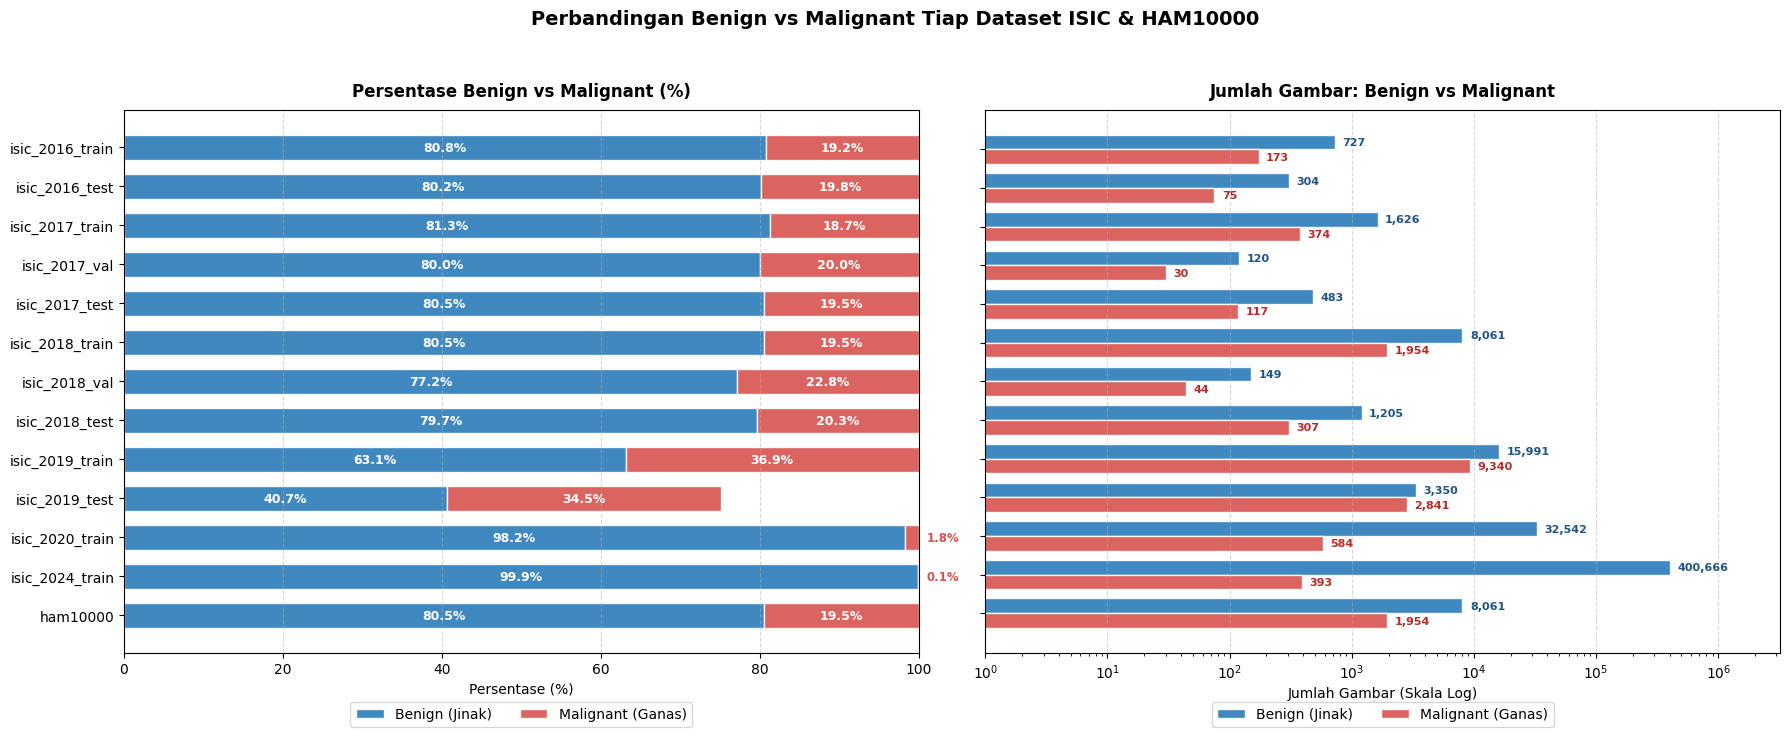

In [29]:
# visualisasi perbandingan data benign vs malignant per dataset
df_plot = df_class_summary[df_class_summary['raw_total'] > 0].copy()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))

sources = df_plot['Source'].tolist()
y_pos = np.arange(len(sources))

benign_pcts = df_plot['pct_benign_val'].tolist()
malignant_pcts = df_plot['pct_malignant_val'].tolist()
benign_counts = df_plot['raw_benign'].tolist()
malignant_counts = df_plot['raw_malignant'].tolist()

# 1. Grafik persentase (stacked bar)
bar_height = 0.65
ax1.barh(y_pos, benign_pcts, height=bar_height, label='Benign (Jinak)', color='#2b7bba', edgecolor='white', alpha=0.9)
ax1.barh(y_pos, malignant_pcts, height=bar_height, left=benign_pcts, label='Malignant (Ganas)', color='#d9534f', edgecolor='white', alpha=0.9)

ax1.set_yticks(y_pos)
ax1.set_yticklabels(sources, fontsize=10)
ax1.set_xlabel('Persentase (%)', fontsize=10)
ax1.set_title('Persentase Benign vs Malignant (%)', fontsize=12, fontweight='bold', pad=10)
ax1.set_xlim(0, 100)
ax1.legend(loc='lower center', bbox_to_anchor=(0.5, -0.15), ncol=2, frameon=True, fontsize=10)
ax1.grid(axis='x', linestyle='--', alpha=0.5)

# label angka persentase
for i, (b_pct, m_pct) in enumerate(zip(benign_pcts, malignant_pcts)):
    if b_pct > 8:
        ax1.text(b_pct / 2, i, f"{b_pct:.1f}%", ha='center', va='center', color='white', fontweight='bold', fontsize=9)
    if m_pct > 5:
        ax1.text(b_pct + m_pct / 2, i, f"{m_pct:.1f}%", ha='center', va='center', color='white', fontweight='bold', fontsize=9)
    elif m_pct > 0:
        ax1.text(b_pct + m_pct + 1, i, f"{m_pct:.1f}%", ha='left', va='center', color='#d9534f', fontweight='bold', fontsize=8.5)

ax1.invert_yaxis()

# 2. Grafik jumlah gambar (skala log)
bar_width = 0.38
y_ben = y_pos - bar_width/2
y_mal = y_pos + bar_width/2

ax2.barh(y_ben, benign_counts, height=bar_width, label='Benign (Jinak)', color='#2b7bba', edgecolor='white', alpha=0.9)
ax2.barh(y_mal, malignant_counts, height=bar_width, label='Malignant (Ganas)', color='#d9534f', edgecolor='white', alpha=0.9)

ax2.set_yticks(y_pos)
ax2.set_yticklabels([])
ax2.set_xscale('log')
ax2.set_xlabel('Jumlah Gambar (Skala Log)', fontsize=10)
ax2.set_title('Jumlah Gambar: Benign vs Malignant', fontsize=12, fontweight='bold', pad=10)
ax2.legend(loc='lower center', bbox_to_anchor=(0.5, -0.15), ncol=2, frameon=True, fontsize=10)
ax2.grid(axis='x', linestyle='--', alpha=0.5)

# label angka jumlah gambar
for i, (b_cnt, m_cnt) in enumerate(zip(benign_counts, malignant_counts)):
    ax2.text(b_cnt * 1.15, y_ben[i], f"{b_cnt:,}", ha='left', va='center', color='#1f5380', fontsize=8, fontweight='bold')
    ax2.text(m_cnt * 1.15, y_mal[i], f"{m_cnt:,}", ha='left', va='center', color='#b52b27', fontsize=8, fontweight='bold')

ax2.set_xlim(1, max(benign_counts) * 8)
ax2.invert_yaxis()

plt.suptitle('Perbandingan Benign vs Malignant Tiap Dataset ISIC & HAM10000', fontsize=14, fontweight='bold', y=0.98)
plt.tight_layout(rect=[0, 0.05, 1, 0.95])
plt.show()


In [30]:
# mapping keterangan nama medis dan kategori (jinak vs ganas)
CLASS_INFO = {
    'nv': ('Melanocytic Nevus (Tahi Lalat)', 'Jinak (Benign)'),
    'NV': ('Melanocytic Nevus (Tahi Lalat)', 'Jinak (Benign)'),
    'nevus': ('Melanocytic Nevus (Tahi Lalat)', 'Jinak (Benign)'),
    'mel': ('Melanoma', 'Ganas (Malignant)'),
    'MEL': ('Melanoma', 'Ganas (Malignant)'),
    'melanoma': ('Melanoma', 'Ganas (Malignant)'),
    'bcc': ('Basal Cell Carcinoma', 'Ganas (Malignant)'),
    'BCC': ('Basal Cell Carcinoma', 'Ganas (Malignant)'),
    'akiec': ('Actinic Keratosis', 'Ganas (Malignant)'),
    'AKIEC': ('Actinic Keratosis', 'Ganas (Malignant)'),
    'ak': ('Actinic Keratosis', 'Ganas (Malignant)'),
    'AK': ('Actinic Keratosis', 'Ganas (Malignant)'),
    'scc': ('Squamous Cell Carcinoma', 'Ganas (Malignant)'),
    'SCC': ('Squamous Cell Carcinoma', 'Ganas (Malignant)'),
    'bkl': ('Benign Keratosis', 'Jinak (Benign)'),
    'BKL': ('Benign Keratosis', 'Jinak (Benign)'),
    'seborrheic_keratosis': ('Seborrheic Keratosis', 'Jinak (Benign)'),
    'df': ('Dermatofibroma', 'Jinak (Benign)'),
    'DF': ('Dermatofibroma', 'Jinak (Benign)'),
    'vasc': ('Vascular Lesion', 'Jinak (Benign)'),
    'VASC': ('Vascular Lesion', 'Jinak (Benign)'),
    'benign': ('Benign (Jinak)', 'Jinak (Benign)'),
    'benign (0)': ('Benign (Jinak)', 'Jinak (Benign)'),
    'malignant': ('Malignant (Ganas)', 'Ganas (Malignant)'),
    'malignant (1)': ('Malignant (Ganas)', 'Ganas (Malignant)'),
    'UNK': ('Unknown (Tidak Diketahui)', 'Out of Distribution'),
    'unlabeled (test)': ('Unlabeled Test Set', 'Unlabeled')
}

# rincian detail jumlah sampel per kelas untuk tiap dataset
detailed_class_list = []

for source, info in SOURCES.items():
    fmt = info.get('gt_format')
    p = info.get('gt_path')
    if not p or not os.path.exists(p):
        n_file = len(df_images[df_images['source'] == source]) if 'df_images' in locals() else 10982
        med_desc, kat = CLASS_INFO.get('unlabeled (test)')
        detailed_class_list.append({
            'Dataset Source': source,
            'Nama Kelas': 'unlabeled (test)',
            'Keterangan Medis': med_desc,
            'Kategori': kat,
            'Jumlah Gambar': f"{n_file:,}",
            'raw_cnt': n_file,
            'Persentase': '100.0%'
        })
        continue
        
    gt = ground_truth_dfs.get(source)
    total_samples = len(gt)
    
    if fmt == '2016':
        col = 'label'
        counts = gt[col].astype(str).str.lower().value_counts()
        for cls_name, cnt in counts.items():
            name_clean = 'malignant' if cls_name in ['malignant', '1.0', '1'] else 'benign'
            med_desc, kat = CLASS_INFO.get(name_clean, (name_clean, '-'))
            detailed_class_list.append({
                'Dataset Source': source,
                'Nama Kelas': name_clean,
                'Keterangan Medis': med_desc,
                'Kategori': kat,
                'Jumlah Gambar': f"{cnt:,}",
                'raw_cnt': cnt,
                'Persentase': f"{round(cnt / total_samples * 100, 2)}%"
            })
    elif fmt == '2017':
        n_mel = int((gt['melanoma'] == 1.0).sum())
        n_sk = int((gt['seborrheic_keratosis'] == 1.0).sum())
        n_nev = total_samples - n_mel - n_sk
        for cls_name, cnt in [('nevus', n_nev), ('melanoma', n_mel), ('seborrheic_keratosis', n_sk)]:
            med_desc, kat = CLASS_INFO.get(cls_name, (cls_name, '-'))
            detailed_class_list.append({
                'Dataset Source': source,
                'Nama Kelas': cls_name,
                'Keterangan Medis': med_desc,
                'Kategori': kat,
                'Jumlah Gambar': f"{cnt:,}",
                'raw_cnt': cnt,
                'Persentase': f"{round(cnt / total_samples * 100, 2)}%"
            })
    elif fmt in ('onehot7', 'onehot9'):
        cols = [c for c in gt.columns if c not in ('image_id', 'image', 'image_name', 'isic_id', 'score_weight', 'validation_weight')]
        counts_dict = {c: int((gt[c] == 1.0).sum()) for c in cols}
        for c, cnt in sorted(counts_dict.items(), key=lambda x: x[1], reverse=True):
            med_desc, kat = CLASS_INFO.get(c, (c, '-'))
            detailed_class_list.append({
                'Dataset Source': source,
                'Nama Kelas': c,
                'Keterangan Medis': med_desc,
                'Kategori': kat,
                'Jumlah Gambar': f"{cnt:,}",
                'raw_cnt': cnt,
                'Persentase': f"{round(cnt / total_samples * 100, 2)}%"
            })
    elif fmt in ('2020', '2024'):
        tgt_col = 'target' if fmt == '2020' else 'malignant'
        n_mal = int((gt[tgt_col] == 1).sum())
        n_ben = total_samples - n_mal
        for cls_name, cnt in [('benign (0)', n_ben), ('malignant (1)', n_mal)]:
            med_desc, kat = CLASS_INFO.get(cls_name, (cls_name, '-'))
            detailed_class_list.append({
                'Dataset Source': source,
                'Nama Kelas': cls_name,
                'Keterangan Medis': med_desc,
                'Kategori': kat,
                'Jumlah Gambar': f"{cnt:,}",
                'raw_cnt': cnt,
                'Persentase': f"{round(cnt / total_samples * 100, 2)}%"
            })
    elif fmt == 'ham_dx':
        counts = gt['dx'].value_counts()
        for cls_name, cnt in counts.items():
            med_desc, kat = CLASS_INFO.get(cls_name, (cls_name, '-'))
            detailed_class_list.append({
                'Dataset Source': source,
                'Nama Kelas': cls_name,
                'Keterangan Medis': med_desc,
                'Kategori': kat,
                'Jumlah Gambar': f"{cnt:,}",
                'raw_cnt': cnt,
                'Persentase': f"{round(cnt / total_samples * 100, 2)}%"
            })

df_class_detail_all = pd.DataFrame(detailed_class_list)

# tampilkan tabel rincian detail seluruh kelas dengan rapi
pd.set_option('display.max_rows', 100)
print("=== RINCIAN DETAIL JUMLAH & PERSENTASE SAMPEL PER KELAS (SEMUA DATASET) ===\n")
display(df_class_detail_all[['Dataset Source', 'Nama Kelas', 'Keterangan Medis', 'Kategori', 'Jumlah Gambar', 'Persentase']])


=== RINCIAN DETAIL JUMLAH & PERSENTASE SAMPEL PER KELAS (SEMUA DATASET) ===



,Dataset Source,Nama Kelas,Keterangan Medis,Kategori,Jumlah Gambar,Persentase
0,isic_2016_train,benign,Benign (Jinak),Jinak (Benign),727,80.78%
1,isic_2016_train,malignant,Malignant (Ganas),Ganas (Malignant),173,19.22%
2,isic_2016_test,benign,Benign (Jinak),Jinak (Benign),304,80.21%
3,isic_2016_test,malignant,Malignant (Ganas),Ganas (Malignant),75,19.79%
4,isic_2017_train,nevus,Melanocytic Nevus (Tahi Lalat),Jinak (Benign),"1,372",68.6%
5,isic_2017_train,melanoma,Melanoma,Ganas (Malignant),374,18.7%
6,isic_2017_train,seborrheic_keratosis,Seborrheic Keratosis,Jinak (Benign),254,12.7%
7,isic_2017_val,nevus,Melanocytic Nevus (Tahi Lalat),Jinak (Benign),78,52.0%
8,isic_2017_val,melanoma,Melanoma,Ganas (Malignant),30,20.0%
9,isic_2017_val,seborrheic_keratosis,Seborrheic Keratosis,Jinak (Benign),42,28.0%


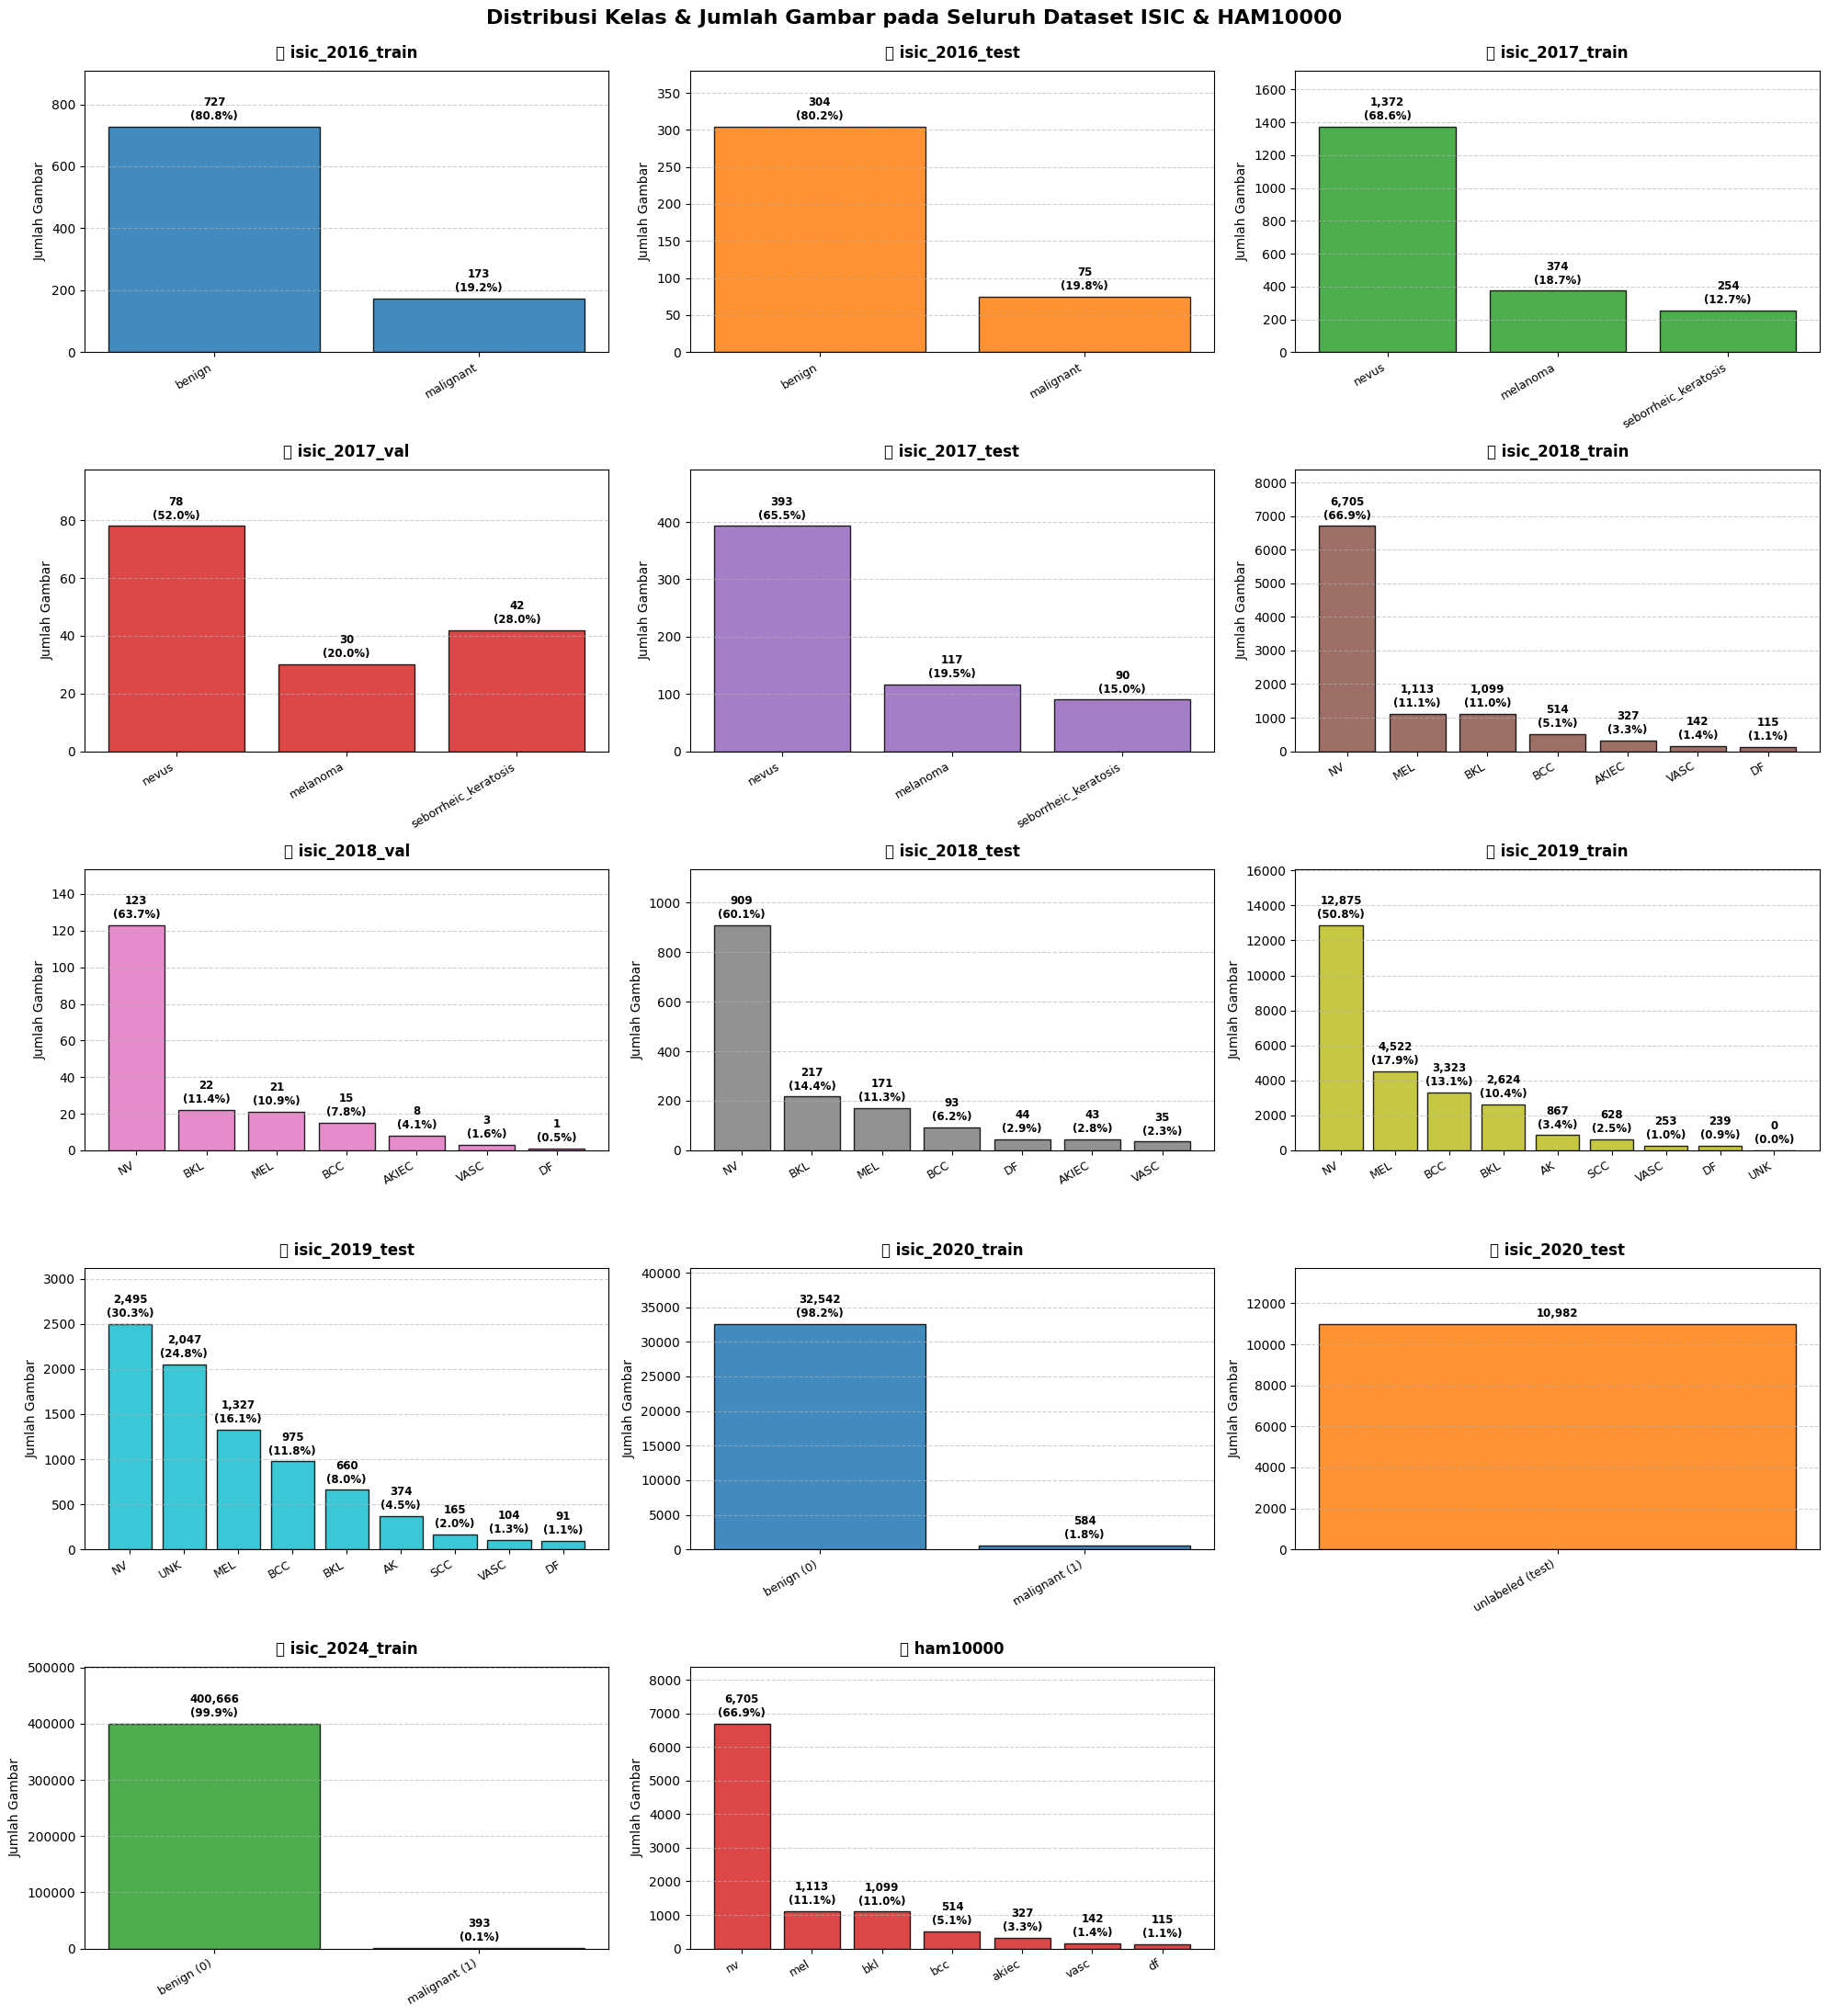

In [31]:
# visualisasi grafik distribusi kelas untuk SEMUA 14 dataset (termasuk isic_2020_test)
sources_to_plot = list(SOURCES.keys())

fig, axes = plt.subplots(5, 3, figsize=(20, 22))
axes_flat = axes.flatten()

colors = sns.color_palette('tab10', 10)

for idx, src in enumerate(sources_to_plot):
    ax = axes_flat[idx]
    df_sub = df_class_detail_all[df_class_detail_all['Dataset Source'] == src]
    
    x_labels = df_sub['Nama Kelas'].tolist()
    y_values = df_sub['raw_cnt'].tolist()
    
    bars = ax.bar(x_labels, y_values, color=colors[idx % len(colors)], edgecolor='black', alpha=0.85)
    ax.set_title(f"📊 {src}", fontsize=12, fontweight='bold', pad=10)
    ax.set_ylabel("Jumlah Gambar", fontsize=10)
    ax.grid(axis='y', linestyle='--', alpha=0.6)
    
    max_y = max(y_values) if y_values else 10
    ax.set_ylim(0, max_y * 1.25)
    
    for bar in bars:
        h = bar.get_height()
        pct = h / sum(y_values) * 100 if sum(y_values) > 0 else 0
        label_text = f"{int(h):,}\n({pct:.1f}%)" if pct < 100 else f"{int(h):,}"
        ax.text(bar.get_x() + bar.get_width() / 2., h + (max_y * 0.02),
                label_text, ha='center', va='bottom', fontsize=8.5, fontweight='bold')
                
    ax.set_xticks(range(len(x_labels)))
    ax.set_xticklabels(x_labels, rotation=30, ha='right', fontsize=9)

# bersihkan subplot kosong yang tidak terpakai
for j in range(len(sources_to_plot), len(axes_flat)):
    fig.delaxes(axes_flat[j])

plt.suptitle("Distribusi Kelas & Jumlah Gambar pada Seluruh Dataset ISIC & HAM10000", fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()


## Langkah 4 — Tabel Perbandingan Karakteristik Antar Dataset 

Tabel perbandingan karakteristik dataset yang dihasilkan dari file dataset, Ground Truth CSV, dan file metadata yang terindeks di sistem.

In [32]:
# membuat tabel perbandingan karakteristik secara dinamis dan otomatis
compare_rows = []

for source, info in SOURCES.items():
    year = info.get('year', '-')
    split = info.get('split', '-').capitalize()
    fmt = info.get('gt_format')
    
    # 1. Jumlah gambar dari file fisik terindeks
    n_images = len(df_images[df_images['source'] == source])
    
    # 2. Ekstraksi format kelas & target secara dinamis
    gt = ground_truth_dfs.get(source)
    if gt is not None:
        if fmt == '2016':
            n_classes = '2 (Binary)'
            target_desc = 'benign / malignant'
            label_fmt = 'Binary String/Numeric'
        elif fmt == '2017':
            n_classes = '3 (Multi-col)'
            target_desc = 'melanoma, seborrheic_keratosis, nevus'
            label_fmt = 'Multi-column Binary'
        elif fmt == 'onehot7':
            cols = [c for c in gt.columns if c not in ('image_id', 'score_weight', 'validation_weight')]
            n_classes = f"{len(cols)} (One-hot)"
            target_desc = ', '.join(cols)
            label_fmt = 'One-hot 7 Class'
        elif fmt == 'onehot9':
            cols = [c for c in gt.columns if c not in ('image_id', 'score_weight', 'validation_weight')]
            n_classes = f"{len(cols)} (One-hot)"
            target_desc = ', '.join(cols)
            label_fmt = 'One-hot 9 Class'
        elif fmt == '2020':
            n_classes = '2 (Target) + Detail'
            target_desc = 'Binary (benign/malignant) & Diagnosis Text'
            label_fmt = 'Binary + Metadata'
        elif fmt == '2024':
            n_classes = '2 (Target) + Detail'
            target_desc = 'Binary (benign/malignant) & iddx_1'
            label_fmt = 'Binary + Metadata'
        elif fmt == 'ham_dx':
            n_classes = f"{gt['dx'].nunique()} (String dx)"
            target_desc = ', '.join(sorted(gt['dx'].unique()))
            label_fmt = 'String dx'
        else:
            n_classes = '-'
            target_desc = '-'
            label_fmt = str(fmt)
    else:
        n_classes = 'Unlabeled'
        target_desc = 'Challenge Test (Tanpa Label)'
        label_fmt = 'Unlabeled'

    # 3. Ekstraksi metadata yang tersedia secara dinamis
    meta_cols = []
    for mp_key in ['meta_path', 'supp_path']:
        mp = info.get(mp_key)
        if mp and os.path.exists(mp):
            mdf = pd.read_csv(mp, nrows=2)
            meta_cols.extend([c for c in mdf.columns if c not in ['image_id', 'image', 'isic_id', 'image_name']])
            
    if gt is not None:
        extra = [c for c in gt.columns if c in ['patient_id', 'lesion_id', 'sex', 'age', 'age_approx', 'anatom_site_general_challenge', 'diagnosis', 'dx_type', 'localization', 'dataset']]
        meta_cols.extend(extra)
        
    meta_cols = sorted(list(set(meta_cols)))
    meta_desc = ', '.join(meta_cols) if meta_cols else 'Tidak Ada'

    compare_rows.append({
        'Dataset Source': source,
        'Tahun Rilis': year,
        'Split': split,
        'Jumlah Gambar': f"{n_images:,}",
        'Jumlah Kelas': n_classes,
        'Format Label': label_fmt,
        'Target / Kelas': target_desc,
        'Metadata Tersedia': meta_desc
    })

df_compare_dynamic = pd.DataFrame(compare_rows)
print("=== TABEL PERBANDINGAN KARAKTERISTIK ANTAR DATASET (INSPEKSI DINAMIS) ===\n")
display(df_compare_dynamic)


=== TABEL PERBANDINGAN KARAKTERISTIK ANTAR DATASET (INSPEKSI DINAMIS) ===



,Dataset Source,Tahun Rilis,Split,Jumlah Gambar,Jumlah Kelas,Format Label,Target / Kelas,Metadata Tersedia
0,isic_2016_train,2016,Train,900,2 (Binary),Binary String/Numeric,benign / malignant,Tidak Ada
1,isic_2016_test,2016,Test,379,2 (Binary),Binary String/Numeric,benign / malignant,Tidak Ada
2,isic_2017_train,2017,Train,"2,000",3 (Multi-col),Multi-column Binary,"melanoma, seborrheic_keratosis, nevus","age_approximate, sex"
3,isic_2017_val,2017,Val,150,3 (Multi-col),Multi-column Binary,"melanoma, seborrheic_keratosis, nevus","age_approximate, sex"
4,isic_2017_test,2017,Test,600,3 (Multi-col),Multi-column Binary,"melanoma, seborrheic_keratosis, nevus","age_approximate, sex"
5,isic_2018_train,2018,Train,"10,015",7 (One-hot),One-hot 7 Class,"MEL, NV, BCC, AKIEC, BKL, DF, VASC","diagnosis_confirm_type, lesion_id"
6,isic_2018_val,2018,Val,193,7 (One-hot),One-hot 7 Class,"MEL, NV, BCC, AKIEC, BKL, DF, VASC",Tidak Ada
7,isic_2018_test,2018,Test,"1,512",7 (One-hot),One-hot 7 Class,"MEL, NV, BCC, AKIEC, BKL, DF, VASC",Tidak Ada
8,isic_2019_train,2019,Train,"25,331",9 (One-hot),One-hot 9 Class,"MEL, NV, BCC, AK, BKL, DF, VASC, SCC, UNK","age_approx, anatom_site_general, lesion_id, sex"
9,isic_2019_test,2019,Test,"8,238",9 (One-hot),One-hot 9 Class,"MEL, NV, BCC, AK, BKL, DF, VASC, SCC, UNK",Tidak Ada


## Langkah 5 — Deteksi & Matrix Overlap Duplikat (`image_id`)

Mendeteksi gambar yang muncul di lebih dari satu dataset dan menghitung irisan (overlap) antar pasangan dataset.

In [33]:
# cari image_id yg muncul di >1 source
dup_group = df_images.groupby('image_id')['source'].apply(lambda x: sorted(list(set(x)))).reset_index()
dup_group['jumlah_source'] = dup_group['source'].apply(len)
df_dups = dup_group[dup_group['jumlah_source'] > 1].sort_values('jumlah_source', ascending=False)

print(f"Total image_id unik yang terduplikasi (>1 dataset): {len(df_dups):,}")
display(df_dups.head(10))


Total image_id unik yang terduplikasi (>1 dataset): 12,886


,image_id,source,jumlah_source
0,ISIC_0000000,"[isic_2016_train, isic_2017_train, isic_2019_t...",3
11346,ISIC_0030597,"[ham10000, isic_2018_train, isic_2019_train]",3
11338,ISIC_0030589,"[ham10000, isic_2018_train, isic_2019_train]",3
11339,ISIC_0030590,"[ham10000, isic_2018_train, isic_2019_train]",3
11340,ISIC_0030591,"[ham10000, isic_2018_train, isic_2019_train]",3
11341,ISIC_0030592,"[ham10000, isic_2018_train, isic_2019_train]",3
11342,ISIC_0030593,"[ham10000, isic_2018_train, isic_2019_train]",3
11343,ISIC_0030594,"[ham10000, isic_2018_train, isic_2019_train]",3
11344,ISIC_0030595,"[ham10000, isic_2018_train, isic_2019_train]",3
11345,ISIC_0030596,"[ham10000, isic_2018_train, isic_2019_train]",3


In [34]:
# hitung pasangan overlap
pair_counter = Counter()
for src_list in df_dups['source']:
    for a, b in combinations(src_list, 2):
        pair_counter[(a, b)] += 1

df_pairs = pd.DataFrame([{'Source 1': k[0], 'Source 2': k[1], 'Jumlah Overlap': v} for k, v in pair_counter.items()])
df_pairs = df_pairs.sort_values('Jumlah Overlap', ascending=False).reset_index(drop=True)

print("=== DAFTAR PASANGAN DATASET YANG OVERLAP ===")
display(df_pairs)


=== DAFTAR PASANGAN DATASET YANG OVERLAP ===


,Source 1,Source 2,Jumlah Overlap
0,ham10000,isic_2018_train,10015
1,ham10000,isic_2019_train,10015
2,isic_2018_train,isic_2019_train,10015
3,isic_2018_test,isic_2019_test,1512
4,isic_2016_train,isic_2017_train,746
5,isic_2017_train,isic_2019_train,717
6,isic_2016_train,isic_2019_train,568
7,isic_2016_test,isic_2017_train,305
8,isic_2016_test,isic_2019_train,258
9,isic_2018_val,isic_2019_test,193


## Langkah 6 — Validasi Duplikat Resmi (ISIC 2020)

ISIC 2020 menyediakan file `ISIC_2020_Training_Duplicates.csv` yang mendokumentasikan pasangan foto dari lesi yang sama.

In [35]:
dup_2020_path = SOURCES['isic_2020_train'].get('dup_path')
if dup_2020_path and os.path.exists(dup_2020_path):
    df_dup_official = pd.read_csv(dup_2020_path)
    print(f"File duplikat resmi ISIC 2020 ditemukan: {len(df_dup_official):,} pasang duplikat")
    display(df_dup_official.head(10))
else:
    print("File duplikat ISIC 2020 tidak ditemukan.")


File duplikat resmi ISIC 2020 ditemukan: 425 pasang duplikat


,image_name_1,image_name_2
0,ISIC_0079038,ISIC_8521950
1,ISIC_0087297,ISIC_4755972
2,ISIC_0088137,ISIC_4201955
3,ISIC_0112097,ISIC_5934021
4,ISIC_0148783,ISIC_7460560
5,ISIC_0149568,ISIC_9022005
6,ISIC_0157530,ISIC_3986853
7,ISIC_0184944,ISIC_2283336
8,ISIC_0192490,ISIC_5956536
9,ISIC_0196945,ISIC_8108340


## Langkah 7 — Eksekusi Hapus Duplikat & Tabel Before vs After

Kita terapkan aturan prioritas dataset (mempertahankan dataset dengan metadata terlengkap dan ground truth terverifikasi), lalu menghapus duplikat untuk mendapatkan dataset bersih unik.

In [36]:
# urutan prioritas dataset (termasuk isic_2020_test)
PRIORITY_ORDER = [
    'isic_2024_train',
    'isic_2020_train',
    'isic_2020_test',
    'isic_2019_train',
    'isic_2019_test',
    'ham10000',
    'isic_2018_train',
    'isic_2018_val',
    'isic_2018_test',
    'isic_2017_train',
    'isic_2017_val',
    'isic_2017_test',
    'isic_2016_train',
    'isic_2016_test',
]

priority_rank = {src: i for i, src in enumerate(PRIORITY_ORDER)}

# gunakan seluruh data gambar fisik terindeks
df_all = df_images.copy()
df_all['priority'] = df_all['source'].map(priority_rank)

# urutkan berdasarkan prioritas terkecil (paling prioritas)
df_sorted = df_all.sort_values(by=['image_id', 'priority'])

# eksekusi hapus duplikat (pertahankan baris pertama / prioritas tertinggi)
df_clean = df_sorted.drop_duplicates(subset='image_id', keep='first').copy()
df_dropped = df_sorted[~df_sorted.index.isin(df_clean.index)].copy()

# petakan setiap data duplikat ke dataset/tahun yang mempertahankan gambar tersebut
kept_map = df_clean.set_index('image_id')['source'].to_dict()
df_dropped['kept_in_source'] = df_dropped['image_id'].map(kept_map)

print(f"Total data awal terindeks (Before): {len(df_all):,}")
print(f"Total data duplikat dihapus: {len(df_dropped):,}")
print(f"Total data bersih unik (After): {len(df_clean):,}")


Total data awal terindeks (Before): 504,500
Total data duplikat dihapus: 23,618
Total data bersih unik (After): 480,882


In [37]:
# buat tabel Before vs After per sumber dataset beserta rincian duplikat ke file/tahun mana
before_counts = df_all['source'].value_counts()
after_counts = df_clean['source'].value_counts()
dropped_counts = df_dropped['source'].value_counts()

rows = []
for src in PRIORITY_ORDER:
    b = before_counts.get(src, 0)
    a = after_counts.get(src, 0)
    d = dropped_counts.get(src, 0)
    pct_drop = round((d / b * 100), 2) if b > 0 else 0
    
    # rincian data duplikat: dipertahankan di file/tahun dataset apa saja
    dropped_src = df_dropped[df_dropped['source'] == src]
    if len(dropped_src) > 0:
        kept_counts = dropped_src['kept_in_source'].value_counts()
        detail_kept = "; ".join([f"{k} ({v:,} gambar)" for k, v in kept_counts.items()])
    else:
        detail_kept = "-"
        
    rows.append({
        'Dataset Source': src,
        'Before (Awal)': b,
        'Duplikat Dihapus': d,
        'After (Bersih)': a,
        '% Berkurang': f"{pct_drop}%",
        'Duplikat Terhadap (Tahun/Dataset Dipertahankan)': detail_kept
    })

df_before_after = pd.DataFrame(rows)

# baris total
total_b = df_before_after['Before (Awal)'].sum()
total_d = df_before_after['Duplikat Dihapus'].sum()
total_a = df_before_after['After (Bersih)'].sum()
total_pct = round((total_d / total_b * 100), 2)

total_row = pd.DataFrame([{
    'Dataset Source': 'TOTAL',
    'Before (Awal)': total_b,
    'Duplikat Dihapus': total_d,
    'After (Bersih)': total_a,
    '% Berkurang': f"{total_pct}%",
    'Duplikat Terhadap (Tahun/Dataset Dipertahankan)': f"Total {total_d:,} duplikat tereliminasi"
}])

df_before_after_all = pd.concat([df_before_after, total_row], ignore_index=True)

print("\n===================== TABEL PERBANDINGAN DATASET BEFORE vs AFTER =====================\n")
display(df_before_after_all)

# tampilkan juga matriks rincian duplikat per sumber/tahun agar semakin jelas
if len(df_dropped) > 0:
    print("\n===================== MATRIKS RINCIAN DUPLIKAT PER FILE TAHUN DATASET =====================\n")
    df_dup_matrix = pd.crosstab(
        df_dropped['source'], 
        df_dropped['kept_in_source'], 
        rownames=['Dataset Dihapus (Duplikat)'], 
        colnames=['Dipertahankan di (Prioritas Tinggi)']
    )
    present_rows = [s for s in PRIORITY_ORDER if s in df_dup_matrix.index]
    present_cols = [s for s in PRIORITY_ORDER if s in df_dup_matrix.columns]
    df_dup_matrix = df_dup_matrix.reindex(index=present_rows, columns=present_cols, fill_value=0)
    display(df_dup_matrix)

    print("\n===================== SAMPEL 10 GAMBAR DUPLIKAT & SUMBER TAHUNNYA =====================\n")
    sample_dups = df_dropped[['image_id', 'source', 'kept_in_source']].head(10).reset_index(drop=True)
    sample_dups.columns = ['Image ID', 'Dataset Sumber (Dihapus)', 'Dipertahankan di (Dataset / Tahun)']
    display(sample_dups)



===================== TABEL PERBANDINGAN DATASET BEFORE vs AFTER =====================



,Dataset Source,Before (Awal),Duplikat Dihapus,After (Bersih),% Berkurang,Duplikat Terhadap (Tahun/Dataset Dipertahankan)
0,isic_2024_train,401059,0,401059,0.0%,-
1,isic_2020_train,33126,0,33126,0.0%,-
2,isic_2020_test,10982,0,10982,0.0%,-
3,isic_2019_train,25331,0,25331,0.0%,-
4,isic_2019_test,8238,0,8238,0.0%,-
5,ham10000,10015,10015,0,100.0%,"isic_2019_train (10,015 gambar)"
6,isic_2018_train,10015,10015,0,100.0%,"isic_2019_train (10,015 gambar)"
7,isic_2018_val,193,193,0,100.0%,isic_2019_test (193 gambar)
8,isic_2018_test,1512,1512,0,100.0%,"isic_2019_test (1,512 gambar)"
9,isic_2017_train,2000,717,1283,35.85%,isic_2019_train (717 gambar)



===================== MATRIKS RINCIAN DUPLIKAT PER FILE TAHUN DATASET =====================



Dipertahankan di (Prioritas Tinggi),isic_2019_train,isic_2019_test,isic_2017_train,isic_2017_val
Dataset Dihapus (Duplikat),,,,
ham10000,10015,0,0,0
isic_2018_train,10015,0,0,0
isic_2018_val,0,193,0,0
isic_2018_test,0,1512,0,0
isic_2017_train,717,0,0,0
isic_2017_val,2,0,0,0
isic_2017_test,1,0,0,0
isic_2016_train,568,0,254,1
isic_2016_test,258,0,82,0



===================== SAMPEL 10 GAMBAR DUPLIKAT & SUMBER TAHUNNYA =====================



,Image ID,Dataset Sumber (Dihapus),Dipertahankan di (Dataset / Tahun)
0,ISIC_0000000,isic_2017_train,isic_2019_train
1,ISIC_0000000,isic_2016_train,isic_2019_train
2,ISIC_0000001,isic_2017_train,isic_2019_train
3,ISIC_0000001,isic_2016_train,isic_2019_train
4,ISIC_0000002,isic_2017_train,isic_2019_train
5,ISIC_0000002,isic_2016_train,isic_2019_train
6,ISIC_0000003,isic_2017_train,isic_2019_train
7,ISIC_0000003,isic_2016_test,isic_2019_train
8,ISIC_0000004,isic_2017_train,isic_2019_train
9,ISIC_0000004,isic_2016_train,isic_2019_train


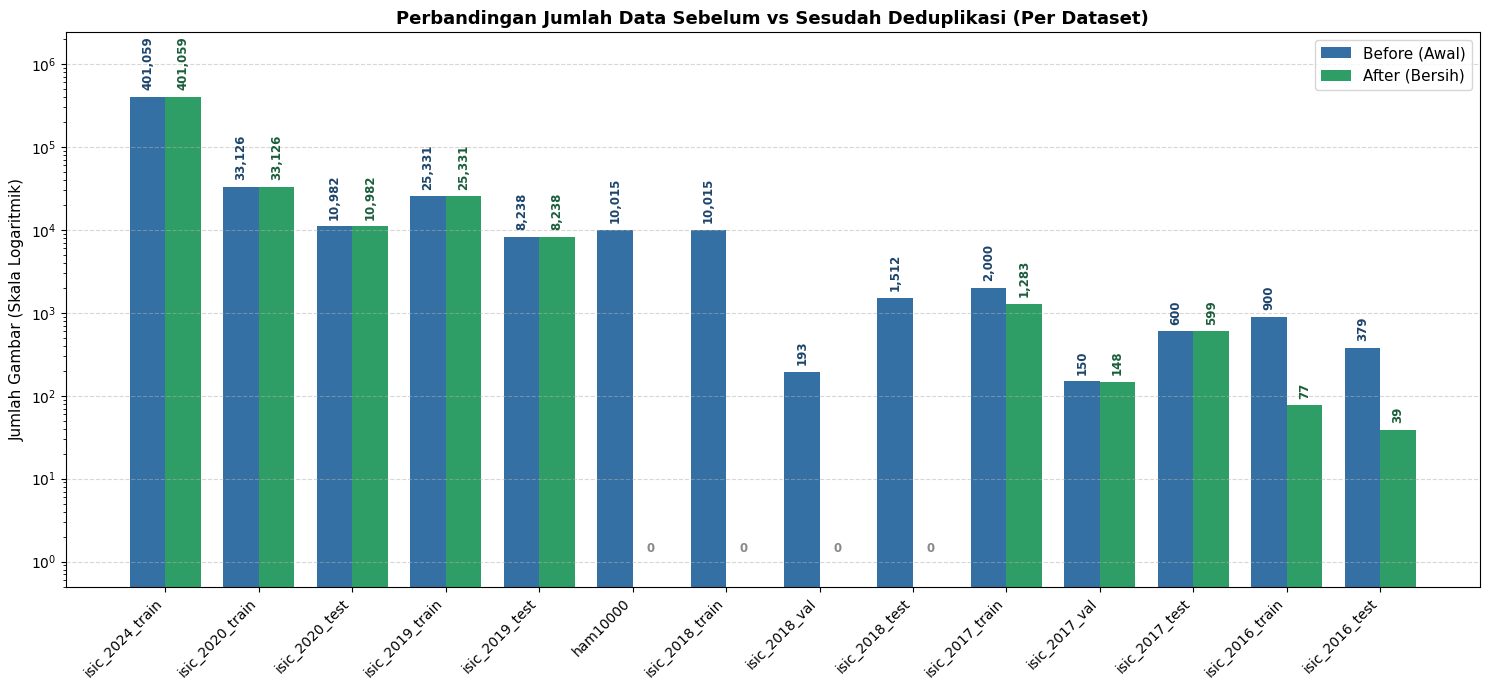

In [38]:
# visualisasi perbandingan Before vs After dengan label angka
fig, ax = plt.subplots(figsize=(15, 7))
x = np.arange(len(df_before_after))
width = 0.38

rects1 = ax.bar(x - width/2, df_before_after['Before (Awal)'], width=width, label='Before (Awal)', color='#3470a3')
rects2 = ax.bar(x + width/2, df_before_after['After (Bersih)'], width=width, label='After (Bersih)', color='#2e9e66')

# tambahkan label angka di atas setiap batang
for rect in rects1:
    h = rect.get_height()
    if h > 0:
        ax.text(rect.get_x() + rect.get_width()/2., h * 1.2, f'{int(h):,}',
                ha='center', va='bottom', fontsize=8.5, rotation=90, color='#1d456b', fontweight='bold')

for rect in rects2:
    h = rect.get_height()
    if h > 0:
        ax.text(rect.get_x() + rect.get_width()/2., h * 1.2, f'{int(h):,}',
                ha='center', va='bottom', fontsize=8.5, rotation=90, color='#1b5e3b', fontweight='bold')
    else:
        # jika 0 gambar tersisa setelah deduplikasi
        ax.text(rect.get_x() + rect.get_width()/2., 1.2, '0',
                ha='center', va='bottom', fontsize=8.5, color='#888888', fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(df_before_after['Dataset Source'], rotation=45, ha='right', fontsize=10)
ax.set_ylabel('Jumlah Gambar (Skala Logaritmik)', fontsize=11)
ax.set_yscale('log')
ax.set_ylim(0.5, df_before_after['Before (Awal)'].max() * 6)
ax.set_title('Perbandingan Jumlah Data Sebelum vs Sesudah Deduplikasi (Per Dataset)', fontsize=13, fontweight='bold')
ax.legend(fontsize=11, loc='upper right')
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


## Langkah 8 — Simpan Metadata Dataset Bersih

Simpan hasil dataset bersih ke file CSV agar siap digunakan untuk tahap riset dan pemodelan berikutnya.

In [39]:
# simpan hasil bersih final ke CSV
output_clean_path = os.path.join(ROOT, 'dataset_clean_final.csv')
cols_to_save = ['image_id', 'source', 'filepath']
df_clean[cols_to_save].to_csv(output_clean_path, index=False)

print(f"Dataset bersih berhasil disimpan ke: {output_clean_path}")
print(f"Total baris data bersih: {len(df_clean):,}")
print("\nContoh 10 baris pertama dataset bersih:")
display(df_clean[cols_to_save].head(10))


Dataset bersih berhasil disimpan ke: C:\Users\ARII\Downloads\Data Understanding Isic & Ham10k\Dataset\dataset_clean_final.csv
Total baris data bersih: 480,882

Contoh 10 baris pertama dataset bersih:


,image_id,source,filepath
15749,ISIC_0000000,isic_2019_train,C:\Users\ARII\Downloads\Data Understanding Isi...
15750,ISIC_0000001,isic_2019_train,C:\Users\ARII\Downloads\Data Understanding Isi...
15751,ISIC_0000002,isic_2019_train,C:\Users\ARII\Downloads\Data Understanding Isi...
15752,ISIC_0000003,isic_2019_train,C:\Users\ARII\Downloads\Data Understanding Isi...
15753,ISIC_0000004,isic_2019_train,C:\Users\ARII\Downloads\Data Understanding Isi...
15754,ISIC_0000006,isic_2019_train,C:\Users\ARII\Downloads\Data Understanding Isi...
15755,ISIC_0000007,isic_2019_train,C:\Users\ARII\Downloads\Data Understanding Isi...
15756,ISIC_0000008,isic_2019_train,C:\Users\ARII\Downloads\Data Understanding Isi...
15757,ISIC_0000009,isic_2019_train,C:\Users\ARII\Downloads\Data Understanding Isi...
15758,ISIC_0000010,isic_2019_train,C:\Users\ARII\Downloads\Data Understanding Isi...


## Langkah 9 — Slicing & Patient-Level Splitting (ISIC 2024)

Dataset tabular ISIC 2024 berukuran sangat besar (~401k baris) dengan distribusi kelas yang sangat *imbalanced* (hanya 393 kasus ganas/malignant).

Untuk kebutuhan eksperimen dan efisiensi komputasi:
1. **Under-sampling / Slicing (1:1)**: Mengambil seluruh 393 sampel kanker (`target=1`) dan 393 sampel jinak (`target=0`) secara acak, menghasilkan subset seimbang 786 sampel.
2. **Patient-Level Split (80:20)**: Membagi data menjadi Train (80%) dan Test (20%) menggunakan `GroupShuffleSplit` berbasis `patient_id` agar foto dari pasien yang sama tidak bercampur antara data latih dan uji (*mencegah data leakage*).

In [40]:
from sklearn.model_selection import GroupShuffleSplit

# 1. Load metadata ISIC 2024
meta_path_2024 = os.path.join(ROOT, 'isic 2024', 'ISIC_2024_Training_Input', 'ISIC_2024_Training_Input', 'metadata.csv')
gt_path_2024 = os.path.join(ROOT, 'isic 2024', 'ISIC_2024_Training_Input', 'ISIC_2024_Training_GroundTruth.csv')

df_meta_2024 = pd.read_csv(meta_path_2024)

# siapkan kolom target biner (0: benign, 1: malignant)
if 'target' not in df_meta_2024.columns:
    if 'malignant' in df_meta_2024.columns:
        df_meta_2024['target'] = df_meta_2024['malignant'].astype(int)
    elif os.path.exists(gt_path_2024):
        df_gt_2024 = pd.read_csv(gt_path_2024)
        id_col = 'isic_id' if 'isic_id' in df_gt_2024.columns else df_gt_2024.columns[0]
        df_meta_2024 = pd.merge(df_meta_2024, df_gt_2024[[id_col, 'malignant']], on=id_col, how='inner')
        df_meta_2024['target'] = df_meta_2024['malignant'].astype(int)

print(f"Total data asli ISIC 2024: {len(df_meta_2024):,} baris ({df_meta_2024['patient_id'].nunique():,} pasien)")
print(f"- Benign    (target=0): {(df_meta_2024['target'] == 0).sum():,}")
print(f"- Malignant (target=1): {(df_meta_2024['target'] == 1).sum():,}\n")

# 2. Slicing data (balanced 1:1)
# ambil semua data malignant, lalu ambil sample benign sejumlah data malignant
df_cancer = df_meta_2024[df_meta_2024['target'] == 1].copy()
n_cancer = len(df_cancer)

df_benign_sampled = df_meta_2024[df_meta_2024['target'] == 0].sample(n=n_cancer, random_state=42).copy()

df_sliced_2024 = pd.concat([df_cancer, df_benign_sampled], ignore_index=True)
df_sliced_2024 = df_sliced_2024.sample(frac=1.0, random_state=42).reset_index(drop=True)

print(f"Hasil Slicing (Balanced 1:1): {len(df_sliced_2024):,} baris")
print(f"- Benign    : {len(df_benign_sampled):,}")
print(f"- Malignant : {n_cancer:,}")
print(f"- Pasien unik di subset: {df_sliced_2024['patient_id'].nunique():,} pasien\n")

# 3. Patient-level split (80% Train, 20% Test)
gss = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=42)
train_idx, test_idx = next(gss.split(df_sliced_2024, groups=df_sliced_2024['patient_id']))

df_train_2024 = df_sliced_2024.iloc[train_idx].copy().reset_index(drop=True)
df_test_2024 = df_sliced_2024.iloc[test_idx].copy().reset_index(drop=True)

# 4. Cek data leakage antar split
train_patients = set(df_train_2024['patient_id'])
test_patients = set(df_test_2024['patient_id'])
overlap = train_patients.intersection(test_patients)

print("Hasil Splitting (80:20):")
print(f"- Train : {len(df_train_2024):,} sampel ({len(train_patients):,} pasien)")
print(f"- Test  : {len(df_test_2024):,} sampel ({len(test_patients):,} pasien)")
print(f"- Pasien overlap: {len(overlap)} (Bebas data leakage)\n")

# 5. Ringkasan tabel distribusi
df_split_summary = pd.DataFrame({
    'Split': ['Train (80%)', 'Test (20%)', 'Total Sliced'],
    'Total Sampel': [len(df_train_2024), len(df_test_2024), len(df_sliced_2024)],
    'Pasien Unik': [len(train_patients), len(test_patients), df_sliced_2024['patient_id'].nunique()],
    'Benign (0)': [(df_train_2024['target'] == 0).sum(), (df_test_2024['target'] == 0).sum(), (df_sliced_2024['target'] == 0).sum()],
    'Malignant (1)': [(df_train_2024['target'] == 1).sum(), (df_test_2024['target'] == 1).sum(), (df_sliced_2024['target'] == 1).sum()],
    '% Malignant': [
        f"{(df_train_2024['target'] == 1).mean()*100:.1f}%",
        f"{(df_test_2024['target'] == 1).mean()*100:.1f}%",
        f"{(df_sliced_2024['target'] == 1).mean()*100:.1f}%"
    ]
})

print("Ringkasan Distribusi Train & Test:")
display(df_split_summary)


Total data asli ISIC 2024: 401,059 baris (1,042 pasien)
- Benign    (target=0): 400,666
- Malignant (target=1): 393

Hasil Slicing (Balanced 1:1): 786 baris
- Benign    : 393
- Malignant : 393
- Pasien unik di subset: 438 pasien

Hasil Splitting (80:20):
- Train : 634 sampel (350 pasien)
- Test  : 152 sampel (88 pasien)
- Pasien overlap: 0 (Bebas data leakage)

Ringkasan Distribusi Train & Test:


,Split,Total Sampel,Pasien Unik,Benign (0),Malignant (1),% Malignant
0,Train (80%),634,350,322,312,49.2%
1,Test (20%),152,88,71,81,53.3%
2,Total Sliced,786,438,393,393,50.0%


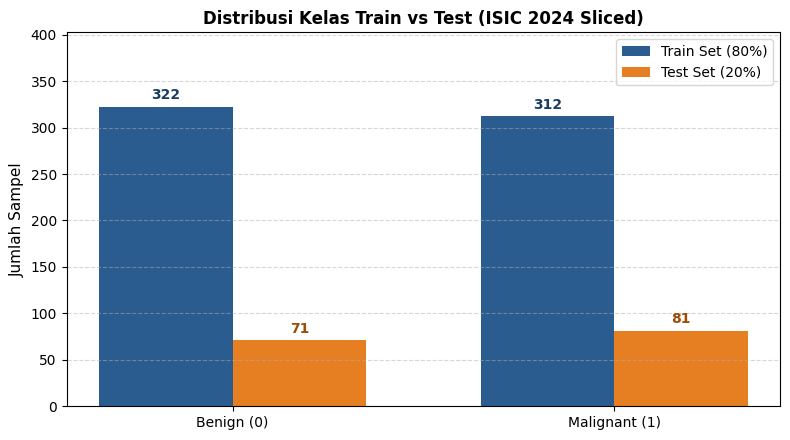

In [41]:
# visualisasi perbandingan distribusi kelas pada data Train dan Test
fig, ax = plt.subplots(figsize=(8, 4.5))

classes = ['Benign (0)', 'Malignant (1)']
train_counts = [(df_train_2024['target'] == 0).sum(), (df_train_2024['target'] == 1).sum()]
test_counts = [(df_test_2024['target'] == 0).sum(), (df_test_2024['target'] == 1).sum()]

x = np.arange(len(classes))
width = 0.35

rects1 = ax.bar(x - width/2, train_counts, width, label='Train Set (80%)', color='#2b5c8f')
rects2 = ax.bar(x + width/2, test_counts, width, label='Test Set (20%)', color='#e67e22')

# label angka di atas bar
for rect in rects1:
    h = rect.get_height()
    ax.text(rect.get_x() + rect.get_width()/2., h + 5, f'{int(h)}', ha='center', va='bottom', fontweight='bold', color='#1a3d61')

for rect in rects2:
    h = rect.get_height()
    ax.text(rect.get_x() + rect.get_width()/2., h + 5, f'{int(h)}', ha='center', va='bottom', fontweight='bold', color='#9c4d07')

ax.set_title('Distribusi Kelas Train vs Test (ISIC 2024 Sliced)', fontsize=12, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(classes, fontsize=10)
ax.set_ylabel('Jumlah Sampel', fontsize=11)
ax.set_ylim(0, max(train_counts) * 1.25)
ax.legend(fontsize=10)
ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()
